# Exercise Graph 2
create a graph where you pass in a single list of integers along with a name and an operation. If the operation is a "+", you add the elements and if it is a "*" , you multiply the elements, all within the same node.
Input {"name": "Jack Sparrow", "values": [1, 2, 3, 4], "operation":"*"}

Output "Hi Jack Sparrow, your answer is: 24

In [3]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [4]:
# Creating Agent State

class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    result: str

In [7]:
def compute_answer(state: AgentState) -> AgentState:
    values = state["values"]

    if state["operation"] == "+":
        answer = sum(values)
    elif state["operation"] == "*":
        answer = 1
        for value in values:
            answer *= value
    else:
        raise ValueError('operation must be "+" or "*"')

    state["result"] = f"Hi {state['name']}, your answer is: {answer}"
    return state

In [9]:
graph = StateGraph(AgentState)

graph.add_node("computer", compute_answer)
graph.set_entry_point("computer")
graph.set_finish_point("computer")

app = graph.compile()

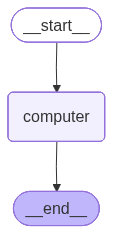

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
answer = app.invoke({"name": "Jack Sparrow", "values":[1, 2, 3, 4], "operation":"*"})

print(answer["result"])

Hi Jack Sparrow, your answer is: 24
